In [1]:
import qsharp
import random
import json
import time
from diskcache import Cache
from matplotlib import pyplot as plt

cache = Cache("~/quant-arith-cache/re-multipliers")
qsharp.init(project_root="../")

@cache.memoize()
def estimate_resources_multiply(op, n):
    est = qsharp.estimate(f"EstimateUtils.RunMultiply({n},{op})")
    return json.dumps(est)    

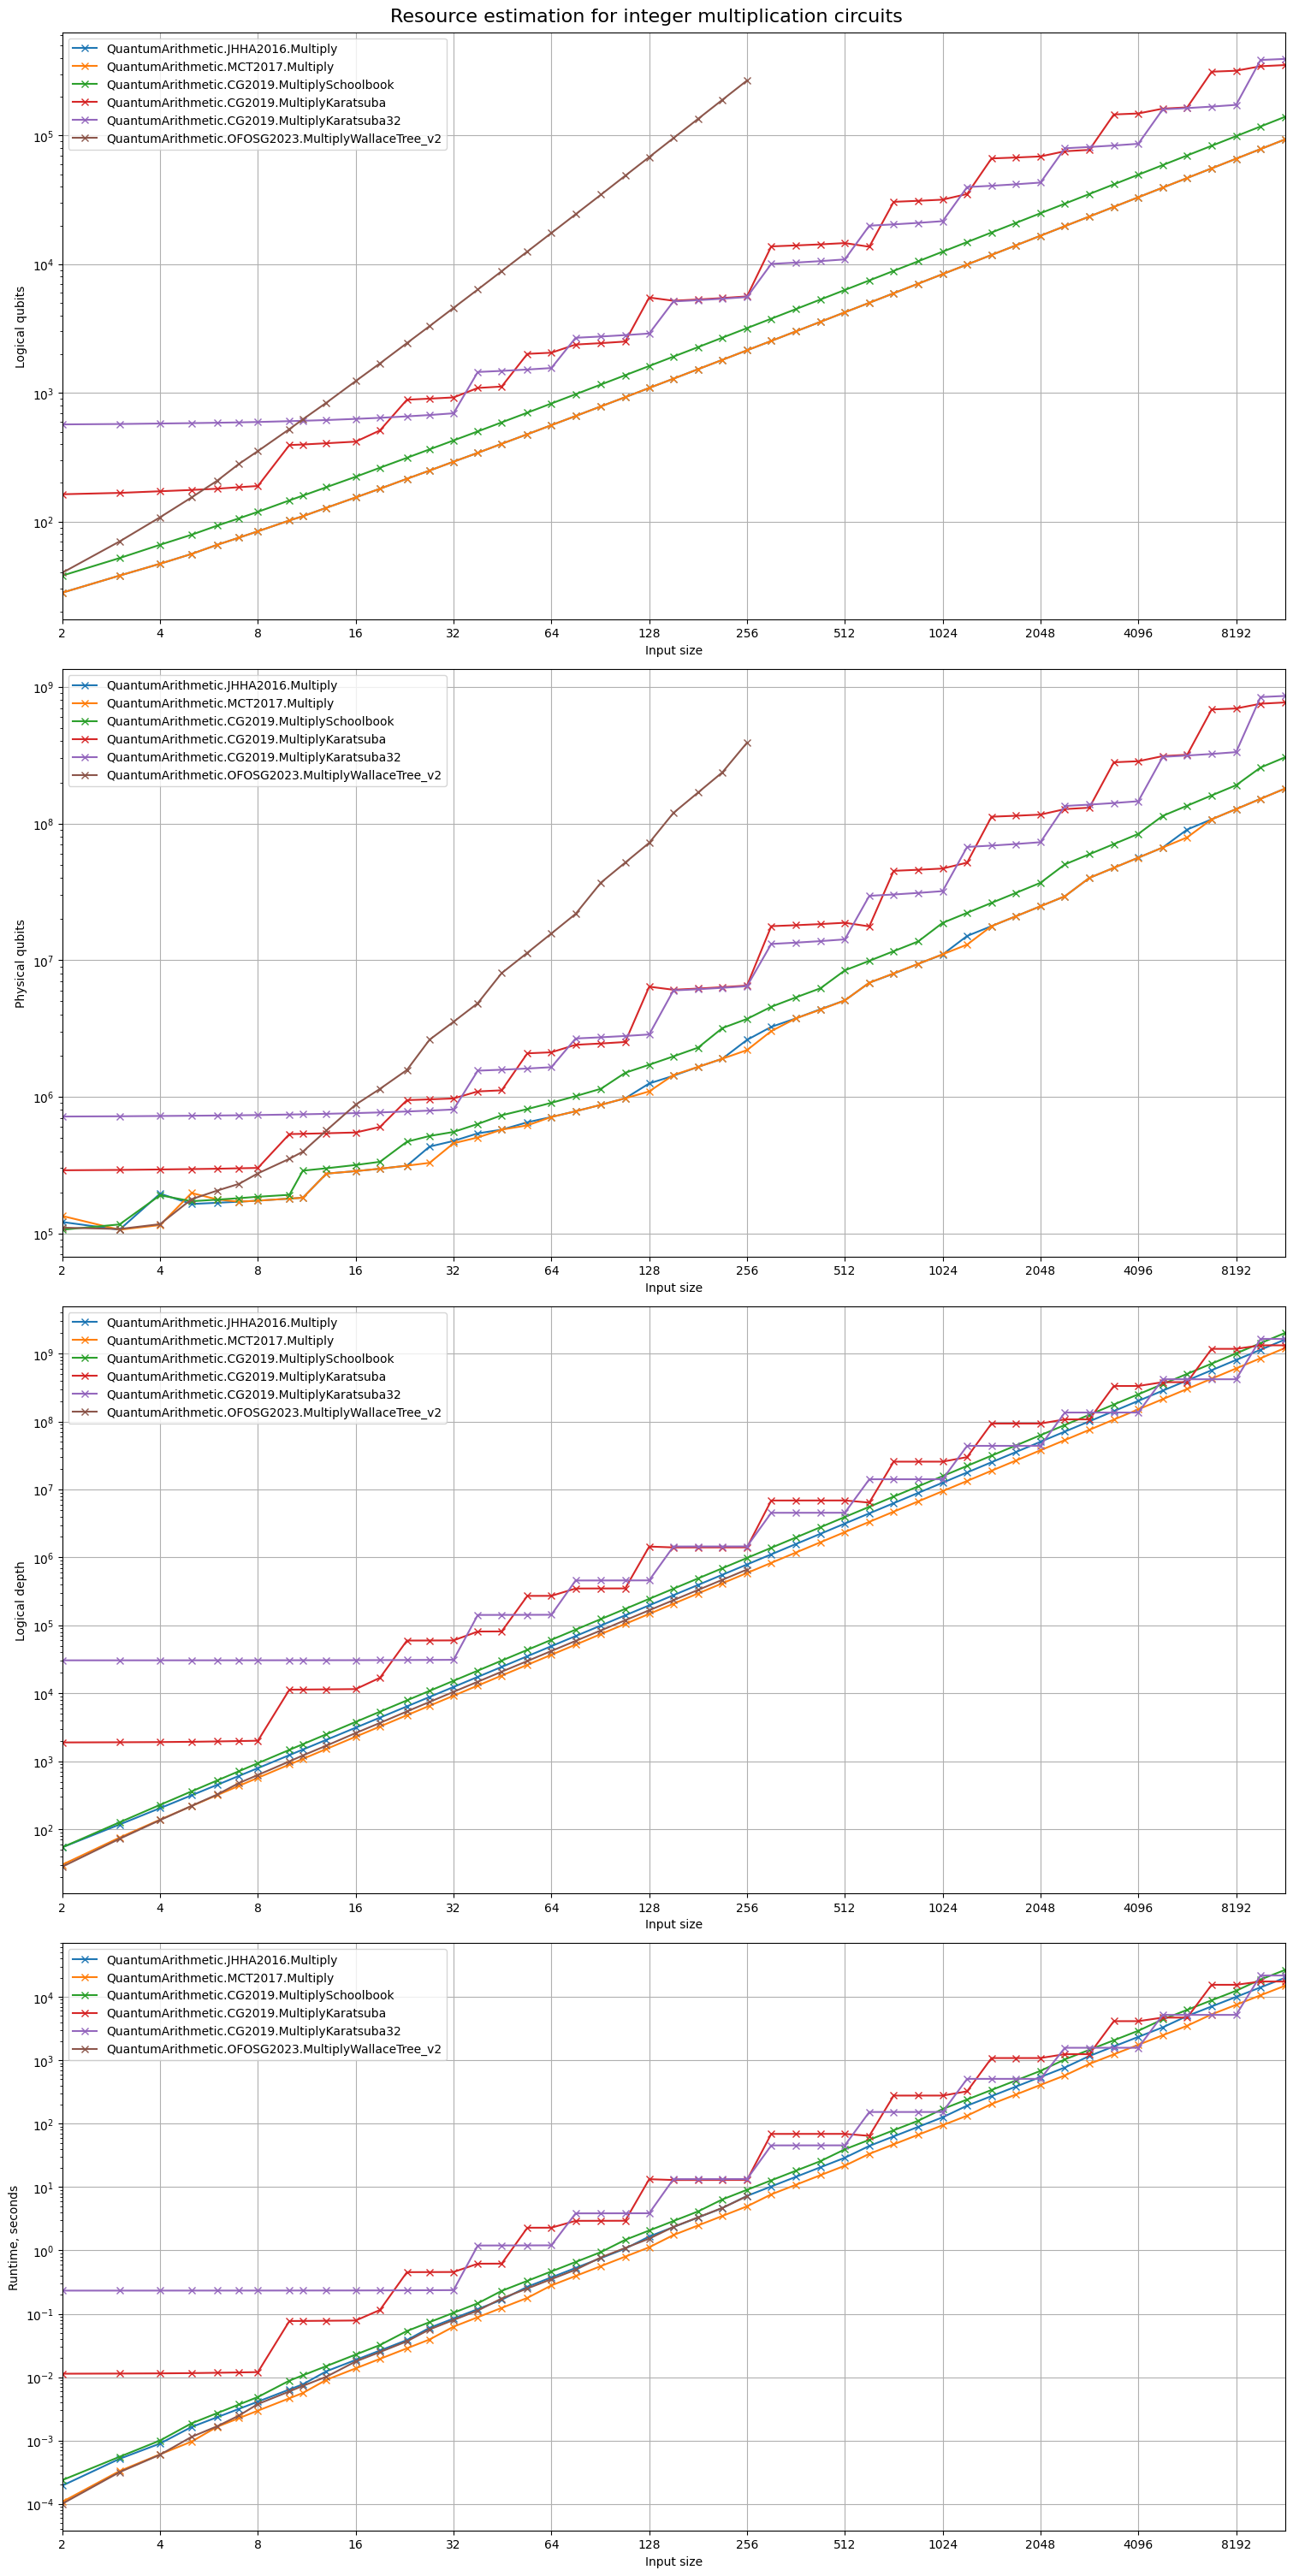

In [2]:
ops = [
  "QuantumArithmetic.JHHA2016.Multiply", 
  "QuantumArithmetic.MCT2017.Multiply", 
  "QuantumArithmetic.CG2019.MultiplySchoolbook",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba",
  "QuantumArithmetic.CG2019.MultiplyKaratsuba32",   
  "QuantumArithmetic.OFOSG2023.MultiplyWallaceTree_v2", 
]

small_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,33)]
default_n_range = [2,3] + [int(round(2**(0.25*i))) for i in range(8,55)]
tick_n_range = [2**i for i in range(1,14)]
n_ranges = {op: default_n_range for op in ops}
n_ranges["QuantumArithmetic.OFOSG2023.MultiplyWallaceTree"] = small_n_range
n_ranges["QuantumArithmetic.OFOSG2023.MultiplyWallaceTree_v2"] = small_n_range

metrics = ["Logical qubits", "Physical qubits", "Logical depth", "Runtime, seconds"]
charts = [{op: [] for op in ops} for _ in range(len(metrics))]

for op in ops:
    for n in n_ranges[op]:
        t0=time.time()
        estimates = json.loads(estimate_resources_multiply(op, n))
        #print(n, op, time.time()-t0, flush=True)
        charts[0][op].append(estimates['physicalCounts']['breakdown']['algorithmicLogicalQubits'])
        charts[1][op].append(estimates['physicalCounts']['physicalQubits'])
        charts[2][op].append(estimates['physicalCounts']['breakdown']['logicalDepth'])
        charts[3][op].append(estimates['physicalCounts']['runtime']/10**9)
        
plt.rcParams['xtick.minor.size'] = 0
plt.rcParams['xtick.minor.width'] = 0    
fig, ax = plt.subplots(figsize=(15, 30), nrows=len(metrics), ncols=1, constrained_layout=True)
for i in range(len(metrics)):
    for op in ops:
        ax[i].plot(n_ranges[op], charts[i][op], label=op, marker='x')
    ax[i].set_xlim([2,max(max(n_ranges[op]) for op in ops)])
    ax[i].legend()
    ax[i].set_xlabel('Input size')
    ax[i].set_ylabel(metrics[i])
    ax[i].set_xscale('log')
    ax[i].set_yscale('log')
    ax[i].set_xticks(tick_n_range)
    ax[i].set_xticklabels(tick_n_range)
    ax[i].grid()
fig.suptitle("Resource estimation for integer multiplication circuits", fontsize=16)
plt.show()